<a href="https://colab.research.google.com/github/vishalyadav5451/Google_Colab/blob/main/RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
churn_data = {
    "tenure" : [1,2,3,10,12,15,20,25,30,35],
    "monthly_charges" : [70,80,60,30,40,20,50,55,45,35],
    "total_charges": [70,160,180,300,480,300,1000,1375,1350,1225],
    "churn": [1,1,1,0,0,0,0,0,0,0]
}

In [ ]:
import pandas as pd
df = pd.DataFrame(churn_data)

In [ ]:
df

,tenure,monthly_charges,total_charges,churn
0,1,70,70,1
1,2,80,160,1
2,3,60,180,1
3,10,30,300,0
4,12,40,480,0
5,15,20,300,0
6,20,50,1000,0
7,25,55,1375,0
8,30,45,1350,0
9,35,35,1225,0


In [ ]:
num_cols = [
    'tenure',	'monthly_charges',	'total_charges'
]

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
sc = StandardScaler()
df[num_cols] = sc.fit_transform(df[num_cols])

In [ ]:
df


,tenure,monthly_charges,total_charges,churn
0,-1.258021,1.230582,-1.138994,1
1,-1.170048,1.802946,-0.960406,1
2,-1.082074,0.658218,-0.920720,1
3,-0.466260,-1.058873,-0.682603,0
4,-0.290313,-0.486509,-0.325427,0
5,-0.026392,-1.631237,-0.682603,0
6,0.413476,0.085855,0.706415,0
7,0.853343,0.372036,1.450531,0
8,1.293211,-0.200327,1.400923,0
9,1.733078,-0.772691,1.152884,0


In [ ]:
x = df.drop('churn' , axis=1)
y = df['churn']

In [ ]:
from sklearn.model_selection import train_test_split

x_train , x_test ,y_train , y_test = train_test_split(x ,y , test_size=0.2 , random_state = 42)

In [ ]:
x_train.shape

(8, 3)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100 , random_state=42)
rf.fit(x_train , y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
pred = rf.predict(x_test)
pred

array([0, 1], dtype=int64)

In [ ]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

print("Accuracy:", accuracy_score(y_test , pred))
print(confusion_matrix(y_test , pred))
print(classification_report(y_test , pred))


Accuracy: 1.0
[[1 0]
 [0 1]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [ ]:
new_customer = pd.DataFrame([[1,1,1]] ,
                            columns = ["tenure", "monthly_charges", "total_charges"])

In [ ]:
churn_pred = rf.predict(new_customer)

In [ ]:
if churn_pred[0] == 1 :
    print("customer will leave")
else :
    print("customer will stay")

customer will stay


In [ ]:
print(y_test.values)
print(pred)

[0 1]
[0 1]


In [ ]:
train_score = rf.score(x_train , y_train)
test_score = rf.score(x_test , y_test)

print("train score",train_score)
print(test_score)

train score 1.0
1.0


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf , x, y, cv=5)

/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


In [ ]:
print(scores)

[1. 1. 1. 1. 1.]


In [ ]:
scores.mean()


np.float64(1.0)

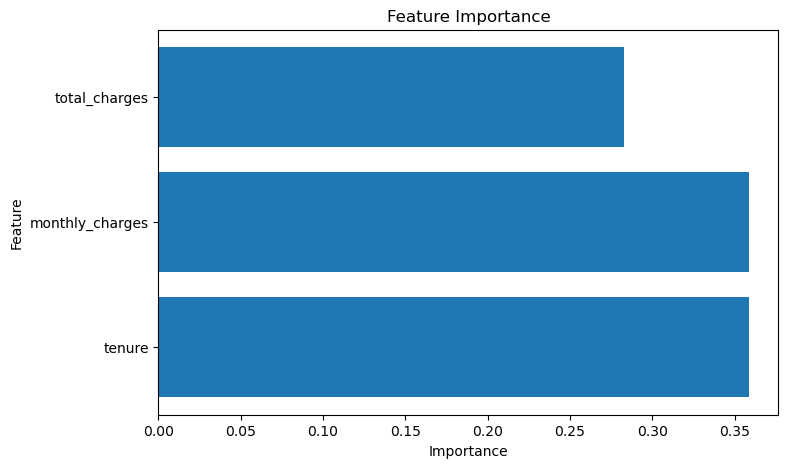

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance










import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.show()

